# **Evaluasi — Multi-Modal Fusion Stacking Ensemble**
**Tahap:** Load hasil modeling → Metrik Evaluasi → Visualisasi → Interpretasi

**Prasyarat:** Jalankan `FEATURE_ENGINEERING.ipynb` dan `MODELING.ipynb` terlebih dahulu.

## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    RocCurveDisplay
)

print('Library berhasil diimpor!')

Library berhasil diimpor!


## **Load Hasil Modeling**

In [2]:
hasil    = pd.read_csv('../result/hasil_prediksi.csv')
coef_df  = pd.read_csv('../result/meta_learner_coef.csv')

y_test       = hasil['y_test'].values
y_pred       = hasil['y_pred'].values
y_pred_proba = hasil['y_pred_proba'].values
P_fisik_test = hasil['P_fisik_test'].values
P_kimia_test = hasil['P_kimia_test'].values

print('Data berhasil dimuat!')
print(f'Jumlah sampel test: {len(y_test)}')

Data berhasil dimuat!
Jumlah sampel test: 64


## **Metrik Evaluasi**

In [3]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('  EVALUASI MULTI-MODAL FUSION STACKING')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Gallstone', 'Gallstone']))

  EVALUASI MULTI-MODAL FUSION STACKING
  Accuracy  : 0.7969
  ROC-AUC   : 0.9004
  F1-Score  : 0.7964

Classification Report:
              precision    recall  f1-score   support

No Gallstone       0.83      0.75      0.79        32
   Gallstone       0.77      0.84      0.81        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64



## **Confusion Matrix**

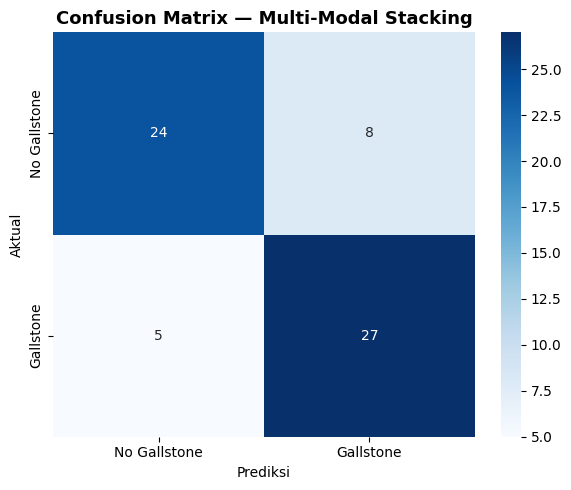

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Gallstone', 'Gallstone'],
    yticklabels=['No Gallstone', 'Gallstone']
)
plt.title('Confusion Matrix — Multi-Modal Stacking', fontsize=13, fontweight='bold')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('../result/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## **ROC Curve**

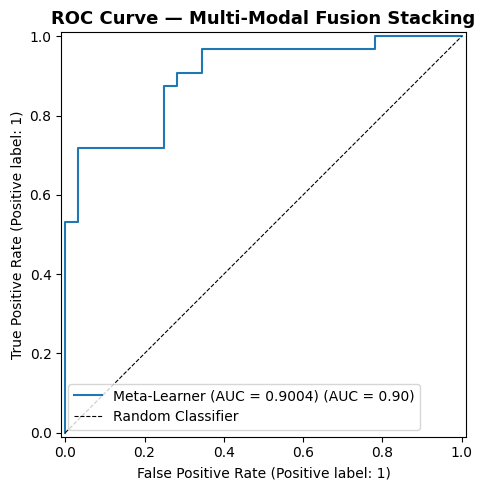

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f'Meta-Learner (AUC = {auc:.4f})',
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Classifier')
ax.set_title('ROC Curve — Multi-Modal Fusion Stacking', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../result/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## **Scatter Meta-Fitur Tier 1**
Visualisasi bagaimana sinyal `P_fisik` vs `P_kimia` memisahkan kelas Gallstone dan No Gallstone.

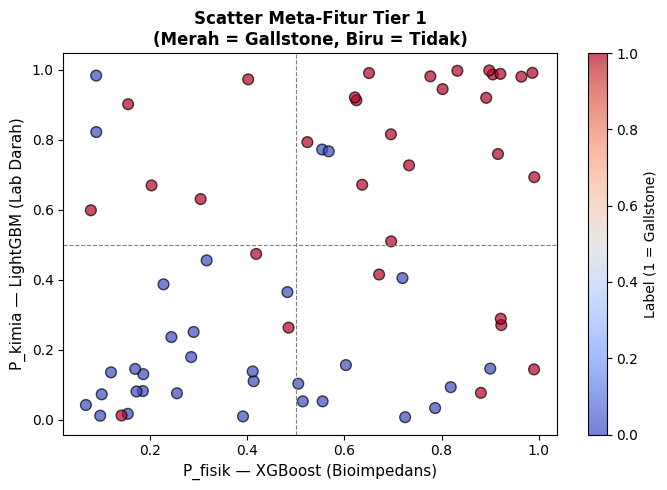

In [6]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    P_fisik_test, P_kimia_test,
    c=y_test, cmap='coolwarm',
    edgecolors='k', alpha=0.7, s=60
)
plt.colorbar(scatter, label='Label (1 = Gallstone)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('P_fisik — XGBoost (Bioimpedans)', fontsize=11)
plt.ylabel('P_kimia — LightGBM (Lab Darah)', fontsize=11)
plt.title('Scatter Meta-Fitur Tier 1\n(Merah = Gallstone, Biru = Tidak)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../result/scatter_meta_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Bobot Meta-Learner — Interpretasi Kontribusi Sinyal

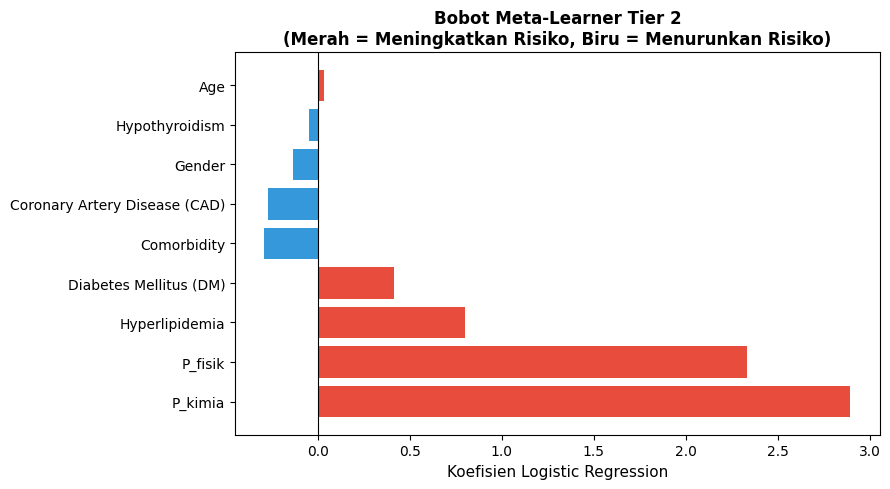

                        Fitur  Koefisien
                      P_kimia   2.893808
                      P_fisik   2.330207
               Hyperlipidemia   0.800193
       Diabetes Mellitus (DM)   0.413855
                  Comorbidity  -0.289756
Coronary Artery Disease (CAD)  -0.268735
                       Gender  -0.132985
               Hypothyroidism  -0.049132
                          Age   0.032301


In [7]:
coef_df = coef_df.sort_values('Koefisien', key=abs, ascending=False)

colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef_df['Koefisien']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Koefisien Logistic Regression', fontsize=11)
plt.title('Bobot Meta-Learner Tier 2\n(Merah = Meningkatkan Risiko, Biru = Menurunkan Risiko)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../result/meta_learner_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df.to_string(index=False))

## 8. Ringkasan Arsitektur Two-Tier Stacking

In [8]:
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║       MULTI-MODAL FUSION STACKING ENSEMBLE — RINGKASAN          ║
╠══════════════════════════════════════════════════════════════════╣
║  TIER 1 (Base Learners)                                         ║
║  ├── Sub-Model A : XGBoost  ← Modalitas Fisik (Bioimpedans)     ║
║  │                  Output : P_fisik (probabilitas kontinu)      ║
║  └── Sub-Model B : LightGBM ← Modalitas Kimia (Lab Darah)       ║
║                   Output : P_kimia (probabilitas kontinu)        ║
╠══════════════════════════════════════════════════════════════════╣
║  META-FEATURES (Input Tier 2)                                   ║
║  [P_fisik | P_kimia | Modalitas Demografi] = 9 kolom            ║
╠══════════════════════════════════════════════════════════════════╣
║  TIER 2 (Meta-Learner)                                          ║
║  └── Logistic Regression → Keputusan Final (Gallstone/Tidak)    ║
╠══════════════════════════════════════════════════════════════════╣
║  HASIL EVALUASI                                                 ║
║  Accuracy : {acc:.4f}                                           ║
║  ROC-AUC  : {auc:.4f}                                           ║
║  F1-Score : {f1:.4f}                                            ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║       MULTI-MODAL FUSION STACKING ENSEMBLE — RINGKASAN          ║
╠══════════════════════════════════════════════════════════════════╣
║  TIER 1 (Base Learners)                                         ║
║  ├── Sub-Model A : XGBoost  ← Modalitas Fisik (Bioimpedans)     ║
║  │                  Output : P_fisik (probabilitas kontinu)      ║
║  └── Sub-Model B : LightGBM ← Modalitas Kimia (Lab Darah)       ║
║                   Output : P_kimia (probabilitas kontinu)        ║
╠══════════════════════════════════════════════════════════════════╣
║  META-FEATURES (Input Tier 2)                                   ║
║  [P_fisik | P_kimia | Modalitas Demografi] = 9 kolom            ║
╠══════════════════════════════════════════════════════════════════╣
║  TIER 2 (Meta-Learner)                                          ║
║  └── Logistic Regression → Keputusan Final (Gallstone/Tidak)    ║
╠════════════════════════════════════════